In [65]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

# Task 1

In [32]:
# Transitions matrix
P = np.array([
    [0.9915, 0.005, 0.0025, 0, 0.001],
    [0, 0.986, 0.005, 0.004, 0.005],
    [0, 0, 0.992, 0.003, 0.005],
    [0, 0, 0, 0.991, 0.009],
    [0, 0, 0, 0, 1]
])

# Parameters
n_states = len(P)
n_sims = 1000
states = np.arange(n_states)

# Array to store results
iters = np.zeros(n_sims)

# Random number generator
rng = np.random.default_rng(30)


local_reaccurance_count = 0
for i in range(n_sims):
    # Inital parameters
    iter = 0
    curr_state = 0
    local_reaccurance = 0

    # Transition to states until death
    while True:
        iter += 1 
        new_state = rng.choice(states, p=P[curr_state])
        
        # If state is the last state (death) then stop
        if new_state == (n_states-1):
            iters[i] = iter
            break

        if new_state == 1:
            local_reaccurance = 1
        
        # Update current state
        curr_state = new_state

    local_reaccurance_count += local_reaccurance


In [35]:
print(f"Propertion of women where the cancer reaccur locally: {local_reaccurance_count / n_sims}")

Propertion of women where the cancer reaccur locally: 0.573


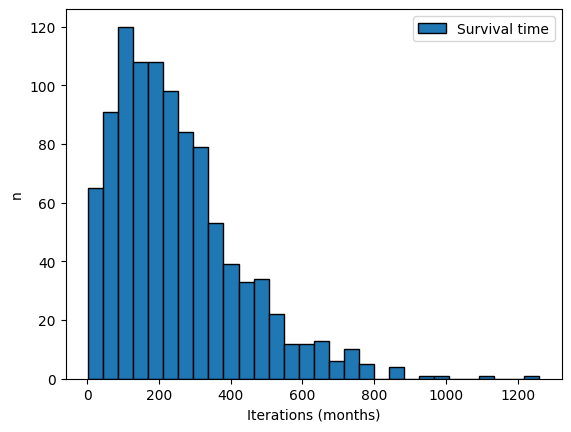

In [34]:
plt.hist(iters,bins=30, edgecolor="black", label="Survival time")
plt.ylabel("n")
plt.xlabel("Iterations (months)")
plt.legend()
plt.show()

# Task 2

In [63]:
# simulate
sims = np.zeros(n_sims, dtype=np.int64)
states = np.arange(n_states)
rng = np.random.default_rng(30)

T = 120

for i in range(n_sims):
    curr_state = 0

    for t in range(T):
        new_state = rng.choice(states, p=P[curr_state])
        curr_state = new_state
    
    sims[i] = curr_state

# Theoretical distr
p0 = np.array([1,0,0,0,0])
pt = p0@np.linalg.matrix_power(P,T)

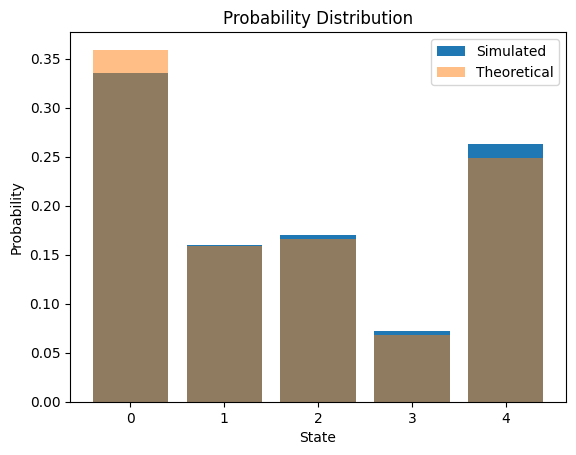

In [66]:
bin_count = np.bincount(sims, minlength=5)
plt.bar(states,bin_count / len(sims), label="Simulated")
plt.bar(states, pt, label="Theoretical", alpha=0.5)
plt.xlabel("State")
plt.ylabel("Probability")
plt.title("Probability Distribution")
plt.xticks(states)
plt.legend()
plt.show()

$\chi^2$-test

In [70]:
T_val, p_val = ss.chisquare(bin_count,1000*pt)
print(T_val,p_val)

2.8584402117411214 0.5817876012777994


# Task 3